# Teacher workload, administrative stress and school recommendation: TALIS 2024

## Introduction

As a Data Lead in a school, I work with data supporting staffing, timetable design and curriculum delivery. Lesson counts alone do not describe workload: preparation, marking, collaboration and administrative expectations also compete for teachers’ time. Frequently I will be asked by the Assistant Principal who is "light" when he is looking to cover something, referring to class count, whereas other teachers will comment on teachers with small class sizes as an equity issue. This project places that practical concern in an international context using published OECD TALIS 2024 indicators for lower-secondary teachers.

The investigation compares 53 education systems through five complementary visual analyses. Total working hours range from 23.2 to 53.0, while estimated non-teaching workload has only a modest positive association with administrative stress. Contrasting profiles show why neither hours nor reported pressure alone adequately describes teachers’ professional experience. Recommendation of the school adds a separate workplace perspective.

These are comparisons of published system estimates, not a staffing formula for an individual school. TALIS does not supply this project with timetable complexity, separate lesson preparations or linked teacher records. Its value here is to identify contrasts worth investigating locally, without treating international associations as explanations of individual experience.

## Research  topic

The investigation distinguishes working time from the activities and pressures associated with it. Working hours refer to tasks related to the job at the surveyed school during the most recent complete calendar week, measured in 60-minute hours. Q15 explicitly frames teaching hours as part of the Q14 total — “Of this total” — so teaching time is treated as a subset of reported total working hours (OECD, n.d.-b, Q14–15). This is neither all employment nor a typical-week norm. Time outside teaching may include preparation, marking, collaboration and administration; it should therefore not be interpreted as administrative work alone.

Administrative stress is considered separately as teachers’ reported response to having too much administrative work. This distinction allows the investigation to explore whether systems with greater non-teaching workloads also report stronger administrative pressure, without assuming that longer hours necessarily imply greater stress. Willingness to recommend one’s school provides a further perspective on how workload–stress patterns coexist with perceptions of the workplace, rather than a direct measure of teacher wellbeing.

Research on teacher stress motivates separating demands from experienced pressure (Kyriacou, 2001). Skaalvik and Skaalvik (2010) examine self-efficacy and burnout, reminding us that professional experience extends beyond hours. Neither construct is measured directly here: administrative stress is one task-related response, and school recommendation is not a burnout scale. The questions therefore address variation, composition, geography, association and visual profiles, rather than test a comprehensive wellbeing model.


## Data collection / Survey design

The project uses published indicators from the OECD Teaching and Learning International Survey (TALIS), accessed through the OECD’s official SDMX API. TALIS gathers questionnaire evidence about teachers’ working conditions and professional experiences. This investigation uses indicators from the teacher questionnaire and restricts retrieval to lower-secondary education (ISCED11_2), providing a consistent educational scope. Accessing published survey indicators is distinct from collecting new responses: the project analyses OECD aggregates rather than individual teacher records.

A standardised international questionnaire supports comparisons, but does not remove differences in national context, translation or respondents’ interpretations. Working hours are self-reported rather than taken from timetables or activity logs, while administrative stress and school recommendation reflect reported perceptions. These limitations need to be considered when interpreting differences between systems. Aggregate associations also cannot establish that the teachers reporting longer hours are the same individuals reporting greater stress.

The public aggregate extracts do not contain identifiable teacher records. Responsible use nevertheless requires accurate attribution to OECD and caution about conclusions that could misrepresent particular systems. The dataset is cited as OECD TALIS 2024 Database (OECD, n.d.-a); the published results provide wider context (OECD, 2025). Official questionnaires, metadata and source notes are retained for verification. OECD’s data terms permit sharing with attribution, subject to additional restrictions and third-party rights; the dataset page directs users to these terms (OECD, 2024). Natural Earth’s separate licence does not license TALIS.


### OECD TALIS data access

The TALIS extracts come from the official OECD SDMX API rather than a third-party mirror. Saved raw CSVs are used by default for reproducibility. An optional refresh requests 2024 explicitly; if the endpoint is unavailable, the saved extract remains the fallback. Source files are retained separately from the processed outputs.

In [1]:
from pathlib import Path

import io

import requests

import pandas as pd

# Work whether the notebook is run from the GitHub folder, project root, or /deliverables

PROJECT_DIR = Path.cwd().resolve()

if not (PROJECT_DIR / "data" / "raw").exists():

    candidates = [PROJECT_DIR / "github", PROJECT_DIR.parent, PROJECT_DIR.parent / "github"]

    PROJECT_DIR = next((c for c in candidates if (c / "data" / "raw").exists()), PROJECT_DIR)

RAW_DIR = PROJECT_DIR / "data" / "raw"

RAW_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://sdmx.oecd.org/public/rest/data"

FLOW = "OECD.EDU.ECS,DSD_TALIS@DF_TALIS,1.0"

print("Raw CSV backup folder: data/raw")


Raw CSV backup folder: data/raw


In [2]:
api_keys = {

    "q14_total_workload": "._Z.Q14_1..MEAN.ISCED11_2._T._T._T._T._T._T",

    "q15_teaching_hours": "._Z.Q15_1..MEAN.ISCED11_2._T._T._T._T._T._T",

    "q77_admin_stress": "._Z.Q77_B_1+Q77_B_2+Q77_B_3+Q77_B_4..COUNT.ISCED11_2._T._T._T._T._T._T",

    "q78_school_recommendation": "._Z.Q78_C_1+Q78_C_2+Q78_C_3+Q78_C_4..COUNT.ISCED11_2._T._T._T._T._T._T",

}

backup_files = {

    "q14_total_workload": "talis_Q14_1_isced11_2.csv",

    "q15_teaching_hours": "talis_Q15_1_isced11_2.csv",

    "q77_admin_stress": "talis_Q77_B_components_isced11_2.csv",

    "q78_school_recommendation": "talis_Q78_C_components_isced11_2.csv",

}


In [3]:
REFRESH_DATA = False  # Use saved extracts by default; set True for an OECD refresh.

def load_oecd_talis_csv(name):

    """Load frozen data, or fetch a live candidate without replacing the snapshot."""

    backup_path = RAW_DIR / backup_files[name]

    if backup_path.exists() and not REFRESH_DATA:

        return pd.read_csv(backup_path)

    url = f"{BASE_URL}/{FLOW}/{api_keys[name]}?startPeriod=2024&endPeriod=2024&format=csv"

    try:

        response = requests.get(url, timeout=120)

        response.raise_for_status()

        df = pd.read_csv(io.StringIO(response.text))

        assert {"REF_AREA", "TIME_PERIOD", "OBS_VALUE"}.issubset(df.columns)

        # Keep the frozen snapshot unchanged: validate live data in later cells.

        # Adopting a new snapshot requires a separate, explicit review.

        print(f"Downloaded {name}: {df.shape[0]} rows, {df.shape[1]} columns")

    except Exception as error:

        if backup_path.exists():

            df = pd.read_csv(backup_path)

            print(f"Used backup for {name}: {df.shape[0]} rows, {df.shape[1]} columns")

            print(f"Endpoint issue: {error}")

        else:

            raise

    return df

q14_total_workload = load_oecd_talis_csv("q14_total_workload")

q15_teaching_hours = load_oecd_talis_csv("q15_teaching_hours")

q77_admin_stress = load_oecd_talis_csv("q77_admin_stress")

q78_school_recommendation = load_oecd_talis_csv("q78_school_recommendation")


In [4]:
# Preview the response structure from one API call

q14_total_workload.head()


,DATAFLOW,REF_AREA,FREQ,MEASURE,UNIT_MEASURE,STATISTICAL_OPERATION,EDUCATION_LEV,AGE,SEX,URBANISATION,INSTITUTION_TYPE,STUDENTS_CHARACTERISTICS,TEACHER_PROFILE,TIME_PERIOD,OBS_VALUE,DECIMALS,OBS_STATUS,UNIT_MULT,ATTRIBUTE_TALIS
0,OECD.EDU.ECS:DSD_TALIS@DF_TALIS(1.0),BHR,_Z,Q14_1,H,MEAN,ISCED11_2,_T,_T,_T,_T,_T,_T,2024,37.526134,2,A,0,Q14_1
1,OECD.EDU.ECS:DSD_TALIS@DF_TALIS(1.0),NZL,_Z,Q14_1,H,MEAN,ISCED11_2,_T,_T,_T,_T,_T,_T,2024,45.437291,2,A,0,Q14_1
2,OECD.EDU.ECS:DSD_TALIS@DF_TALIS(1.0),BEFL,_Z,Q14_1,H,MEAN,ISCED11_2,_T,_T,_T,_T,_T,_T,2024,37.471243,2,A,0,Q14_1
3,OECD.EDU.ECS:DSD_TALIS@DF_TALIS(1.0),COL,_Z,Q14_1,H,MEAN,ISCED11_2,_T,_T,_T,_T,_T,_T,2024,38.687726,2,A,0,Q14_1
4,OECD.EDU.ECS:DSD_TALIS@DF_TALIS(1.0),ALB,_Z,Q14_1,H,MEAN,ISCED11_2,_T,_T,_T,_T,_T,_T,2024,28.586111,2,A,0,Q14_1


## Data overview and pre-processing

### Data overview

The selected data describe lower-secondary teachers through published education-system estimates. The saved extraction diagnostics identify 2024 as the observation year for the selected series. Each source record includes an area identifier, an indicator, a time period, a unit and a reported value. A row is therefore a published estimate for a particular indicator or response category, not an individual teacher.

Four groups of variables support the investigation. Total weekly working hours (Q14_1) and weekly teaching hours (Q15_1) are published as means measured in hours. Administrative stress (Q77_B) concerns having too much administrative work to do; its four response categories run from ‘Not at all’ to ‘A lot’. School recommendation (Q78_C) concerns whether respondents would recommend their school as a good place to work, with categories ranging from ‘Strongly disagree’ to ‘Strongly agree’. The latter two measures are supplied as response-category percentages, not mean scale scores.

These differences in measurement guide interpretation: hours describe reported time, whereas category percentages describe the distribution of reported perceptions. The four source files contain 56, 56, 224 and 224 rows respectively before the explicit exclusions. The category files have four records per system; these are percentages, despite the API’s COUNT operation label.


### Pre-processing

The extracts are restricted to 2024, lower-secondary education and the overall teacher population. Official OECD area labels are used rather than filtering by code length. The OECD aggregate is retained only as a possible benchmark. Belgium is retained at national level, while the Flemish and French Community entries are excluded to avoid overlapping observations. Alberta and Shanghai are retained as participating education systems, not relabelled as Canada or China. Any subsequent map must respect these geographical boundaries.

Checks establish numeric values, unique area–year–indicator records, consistent units, observation flags and plausible ranges. Missing values are not replaced with zero. Duplicates or invalid values trigger investigation rather than automatic removal. The four response-category percentages are checked for completeness and a total close to 100, allowing for rounding.

Non-teaching hours are a difference of published means, not a directly observed mean of individual non-teaching hours. Interpreting this difference as a mean remainder assumes compatible respondent populations and weighting denominators. Q14–15 share the school/week definition, but these aggregate files do not establish identical item-response denominators. High administrative stress combines ‘Quite a bit’ and ‘A lot’, while positive school recommendation combines ‘Agree’ and ‘Strongly agree’. Original response categories are retained because combining them loses detail.

An outer join shows coverage differences before analysis-specific complete-case samples are selected. Outliers are retained unless a source error is established. The resulting table and coverage audit are exported, with hours and percentages kept in their original units. For RQ5 only, per-feature min–max normalisation supports the visual comparison of mixed-unit workload–stress profiles; original-unit values are retained.


In [5]:
# Scope, area labels and explicit inclusion decisions

from IPython.display import display

YEAR = 2024

area_labels = {'ALB': 'Albania', 'ARE': 'United Arab Emirates', 'AUS': 'Australia', 'AUT': 'Austria', 'AZE': 'Azerbaijan', 'BEFL': 'Flemish Community', 'BEFR': 'French Community', 'BEL': 'Belgium', 'BGR': 'Bulgaria', 'BHR': 'Bahrain', 'BRA': 'Brazil', 'CA48': 'Alberta', 'CHL': 'Chile', 'CN09': 'Shanghai', 'COL': 'Colombia', 'CRI': 'Costa Rica', 'CYP': 'Cyprus', 'CZE': 'Czechia', 'DNK': 'Denmark', 'ESP': 'Spain', 'EST': 'Estonia', 'FIN': 'Finland', 'FRA': 'France', 'HRV': 'Croatia', 'HUN': 'Hungary', 'ISL': 'Iceland', 'ISR': 'Israel', 'ITA': 'Italy', 'JPN': 'Japan', 'KAZ': 'Kazakhstan', 'KOR': 'Korea', 'LTU': 'Lithuania', 'LVA': 'Latvia', 'MAR': 'Morocco', 'MKD': 'North Macedonia', 'MLT': 'Malta', 'MNE': 'Montenegro', 'NLD': 'Netherlands', 'NOR': 'Norway', 'NZL': 'New Zealand', 'OECD': 'OECD', 'POL': 'Poland', 'PRT': 'Portugal', 'ROU': 'Romania', 'SAU': 'Saudi Arabia', 'SGP': 'Singapore', 'SRB': 'Serbia', 'SVK': 'Slovak Republic', 'SVN': 'Slovenia', 'SWE': 'Sweden', 'TUR': 'Türkiye', 'USA': 'United States', 'UZB': 'Uzbekistan', 'VNM': 'Viet Nam', 'XKV': 'Kosovo', 'ZAF': 'South Africa'}

extracts = {

    "total_hours": q14_total_workload.copy(),

    "teaching_hours": q15_teaching_hours.copy(),

    "admin_stress": q77_admin_stress.copy(),

    "recommendation": q78_school_recommendation.copy(),

}

exclusions = {

    "OECD": "Aggregate benchmark, not an independent education system",

    "BEFL": "Overlaps with retained Belgium national estimate",

    "BEFR": "Overlaps with retained Belgium national estimate",

}

all_areas = sorted(set().union(*[set(d["REF_AREA"]) for d in extracts.values()]))

assert all(a in area_labels for a in all_areas), "New area: check OECD area metadata"

area_decisions = pd.DataFrame({"REF_AREA": all_areas})

area_decisions["area_name"] = area_decisions["REF_AREA"].map(area_labels)

area_decisions["included"] = ~area_decisions["REF_AREA"].isin(exclusions)

area_decisions["reason"] = area_decisions["REF_AREA"].map(exclusions).fillna("Participating education system")

display(area_decisions.loc[~area_decisions["included"] | area_decisions["REF_AREA"].isin(["CA48", "CN09"])])

checks = []

flag_summary = []

for name, frame in extracts.items():

    frame["TIME_PERIOD"] = pd.to_numeric(frame["TIME_PERIOD"], errors="raise")

    frame["OBS_VALUE"] = pd.to_numeric(frame["OBS_VALUE"], errors="raise")

    frame = frame.loc[(frame["TIME_PERIOD"] == YEAR) & (frame["EDUCATION_LEV"] == "ISCED11_2")].copy()

    assert not frame.empty, f"No matching observations for {name}"

    for dimension in ["AGE", "SEX", "URBANISATION", "INSTITUTION_TYPE", "STUDENTS_CHARACTERISTICS", "TEACHER_PROFILE"]:

        assert frame[dimension].eq("_T").all(), f"Unexpected population slice: {dimension}"

    assert frame["UNIT_MULT"].eq(0).all(), "Check unit multiplier"

    assert frame["FREQ"].eq("_Z").all(), "Check frequency dimension"

    expected_unit = "H" if name in ["total_hours", "teaching_hours"] else "PT_RESP"

    expected_stat = "MEAN" if expected_unit == "H" else "COUNT"

    assert frame["UNIT_MEASURE"].eq(expected_unit).all()

    assert frame["STATISTICAL_OPERATION"].eq(expected_stat).all()

    duplicates = frame.duplicated(["REF_AREA", "TIME_PERIOD", "MEASURE"]).sum()

    assert duplicates == 0, f"Duplicate keys in {name}; investigate rather than drop"

    valid = frame["OBS_VALUE"].dropna()

    assert valid.ge(0).all(), f"Negative values in {name}"

    if expected_unit == "PT_RESP":

        assert valid.le(100).all(), "Percentage above 100"

    flag_summary.append({"extract": name, "OBS_STATUS": str(frame["OBS_STATUS"].unique().tolist()),

                         "ATTRIBUTE_TALIS": str(frame["ATTRIBUTE_TALIS"].unique().tolist())})

    assert frame["OBS_STATUS"].eq("A").all(), "Non-A status: consult OECD metadata before proceeding"

    checks.append({"extract": name, "source_rows": len(frame), "source_areas": frame["REF_AREA"].nunique(),

                   "missing_values": int(frame["OBS_VALUE"].isna().sum()), "duplicate_keys": int(duplicates)})

    extracts[name] = frame.loc[~frame["REF_AREA"].isin(exclusions)].copy()

quality_checks = pd.DataFrame(checks)

display(quality_checks)

display(pd.DataFrame(flag_summary))


,REF_AREA,area_name,included,reason
5,BEFL,Flemish Community,False,Overlaps with retained Belgium national estimate
6,BEFR,French Community,False,Overlaps with retained Belgium national estimate
11,CA48,Alberta,True,Participating education system
13,CN09,Shanghai,True,Participating education system
40,OECD,OECD,False,"Aggregate benchmark, not an independent educat..."


,extract,source_rows,source_areas,missing_values,duplicate_keys
0,total_hours,56,56,0,0
1,teaching_hours,56,56,0,0
2,admin_stress,224,56,0,0
3,recommendation,224,56,0,0


,extract,OBS_STATUS,ATTRIBUTE_TALIS
0,total_hours,['A'],['Q14_1']
1,teaching_hours,['A'],['Q15_1']
2,admin_stress,['A'],"['Q77_B_4', 'Q77_B_3', 'Q77_B_1', 'Q77_B_2']"
3,recommendation,['A'],"['Q78_C_1', 'Q78_C_4', 'Q78_C_2', 'Q78_C_3']"


In [6]:
# Reshape without aggregation and retain all questionnaire categories

key = ["REF_AREA", "TIME_PERIOD"]

total = extracts["total_hours"][key + ["OBS_VALUE"]].rename(columns={"OBS_VALUE": "total_work_hours"})

teaching = extracts["teaching_hours"][key + ["OBS_VALUE"]].rename(columns={"OBS_VALUE": "teaching_hours"})

admin = extracts["admin_stress"].pivot(index=key, columns="MEASURE", values="OBS_VALUE")

recommend = extracts["recommendation"].pivot(index=key, columns="MEASURE", values="OBS_VALUE")

admin_cols = ["Q77_B_1", "Q77_B_2", "Q77_B_3", "Q77_B_4"]

recommend_cols = ["Q78_C_1", "Q78_C_2", "Q78_C_3", "Q78_C_4"]

assert set(admin.columns) == set(admin_cols)

assert set(recommend.columns) == set(recommend_cols)

category_checks = []

for name, frame, columns in [("administrative stress", admin, admin_cols), ("school recommendation", recommend, recommend_cols)]:

    totals = frame[columns].sum(axis=1, min_count=4)

    complete = totals.notna()

    error = (totals.loc[complete] - 100).abs()

    assert error.le(0.1).all(), f"Response shares do not sum to 100: {name}"

    category_checks.append({"measure": name, "complete_category_sets": int(complete.sum()),

                            "incomplete_category_sets": int((~complete).sum()), "largest_rounding_difference": error.max()})

display(pd.DataFrame(category_checks))

# min_count=2 prevents an absent response category from becoming zero

admin["admin_stress_high_pct"] = admin[["Q77_B_3", "Q77_B_4"]].sum(axis=1, min_count=2)

recommend["school_recommend_positive_pct"] = recommend[["Q78_C_3", "Q78_C_4"]].sum(axis=1, min_count=2)

admin = admin.reset_index()

recommend = recommend.reset_index()


,measure,complete_category_sets,incomplete_category_sets,largest_rounding_difference
0,administrative stress,53,0,1.000001e-08
1,school recommendation,53,0,1.399999e-08


In [7]:
# Outer joins expose missing indicators; uniqueness is enforced at every join

analysis_table = total.merge(teaching, on=key, how="outer", validate="one_to_one")

analysis_table = analysis_table.merge(admin, on=key, how="outer", validate="one_to_one")

analysis_table = analysis_table.merge(recommend, on=key, how="outer", validate="one_to_one")

analysis_table["area_name"] = analysis_table["REF_AREA"].map(area_labels)

analysis_table["non_teaching_hours"] = analysis_table["total_work_hours"] - analysis_table["teaching_hours"]

assert analysis_table["non_teaching_hours"].dropna().ge(0).all(), "Teaching exceeds total hours: investigate"

analysis_table = analysis_table.sort_values("area_name").reset_index(drop=True)

indicators = ["total_work_hours", "teaching_hours", "non_teaching_hours", "admin_stress_high_pct", "school_recommend_positive_pct"]

coverage = analysis_table[key + ["area_name"]].copy()

for column in indicators:

    coverage[column + "_available"] = analysis_table[column].notna()

display(analysis_table[indicators].isna().sum().rename("Missing education systems").to_frame())

display(coverage.loc[~coverage.filter(like="_available").all(axis=1)])

# Missingness decisions are made per RQ, not by dropping all incomplete rows globally.

rq_variables = {

    "RQ1": ["total_work_hours"],

    "RQ2": ["teaching_hours", "non_teaching_hours"],

    "RQ3": ["admin_stress_high_pct"],

    "RQ4": ["non_teaching_hours", "admin_stress_high_pct"],

    "RQ5_profiles": ["teaching_hours", "non_teaching_hours", "admin_stress_high_pct"],

}

rq_samples = {rq: analysis_table.dropna(subset=columns).copy() for rq, columns in rq_variables.items()}

display(pd.DataFrame([{"analysis": rq, "included_systems": len(frame),

                        "excluded_for_missing_values": len(analysis_table) - len(frame)} for rq, frame in rq_samples.items()]))

print("RQ5 recommendation coverage:", rq_samples["RQ5_profiles"]["school_recommend_positive_pct"].notna().sum())


,Missing education systems
total_work_hours,0
teaching_hours,0
non_teaching_hours,0
admin_stress_high_pct,0
school_recommend_positive_pct,0


,REF_AREA,TIME_PERIOD,area_name,total_work_hours_available,teaching_hours_available,non_teaching_hours_available,admin_stress_high_pct_available,school_recommend_positive_pct_available


,analysis,included_systems,excluded_for_missing_values
0,RQ1,53,0
1,RQ2,53,0
2,RQ3,53,0
3,RQ4,53,0
4,RQ5_profiles,53,0


RQ5 recommendation coverage: 53


In [8]:
# Preview, descriptive summary and reproducible exports

display(analysis_table[["area_name", "TIME_PERIOD"] + indicators].head(10).round(2))

summary = analysis_table[indicators].describe().T

# Across-system summaries are not pooled teacher-level or OECD weighted estimates

display(summary.round(2))

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

analysis_table.to_csv(PROCESSED_DIR / "talis_education_system_analysis_2024.csv", index=False)

coverage.to_csv(PROCESSED_DIR / "talis_coverage_2024.csv", index=False)

area_decisions.to_csv(PROCESSED_DIR / "talis_area_decisions_2024.csv", index=False)

quality_checks.to_csv(PROCESSED_DIR / "talis_quality_checks_2024.csv", index=False)

summary.to_csv(PROCESSED_DIR / "talis_summary_2024.csv")

print(f"Saved analysis table: {len(analysis_table)} education systems, {YEAR}.")


,area_name,TIME_PERIOD,total_work_hours,teaching_hours,non_teaching_hours,admin_stress_high_pct,school_recommend_positive_pct
0,Albania,2024,28.59,15.81,12.77,31.24,93.45
1,Alberta,2024,46.34,27.08,19.26,38.87,86.03
2,Australia,2024,43.97,19.26,24.71,69.02,82.91
3,Austria,2024,37.63,19.66,17.97,56.57,86.03
4,Azerbaijan,2024,23.17,19.44,3.73,30.19,85.00
5,Bahrain,2024,37.53,24.59,12.93,44.73,81.12
6,Belgium,2024,35.32,18.79,16.53,70.32,84.94
7,Brazil,2024,32.32,23.61,8.72,54.35,89.03
8,Bulgaria,2024,37.97,20.69,17.28,35.58,93.58
9,Chile,2024,38.29,28.43,9.86,56.88,83.65


,count,mean,std,min,25%,50%,75%,max
total_work_hours,53.0,37.39,5.48,23.17,34.75,37.63,40.15,53.01
teaching_hours,53.0,20.97,3.07,15.81,18.93,20.70,22.25,29.30
non_teaching_hours,53.0,16.43,5.88,3.73,12.70,16.75,19.26,35.62
admin_stress_high_pct,53.0,48.30,13.54,24.64,38.32,50.63,56.83,79.27
school_recommend_positive_pct,53.0,84.36,6.58,55.71,81.87,85.00,88.51,93.76


Saved analysis table: 53 education systems, 2024.


The checks found no missing reported values or duplicate keys in the selected extracts. Removing the OECD aggregate and the two overlapping Belgian Community entries left 53 education systems, all with the indicators required for the five research questions. Percentage totals passed the rounding-tolerance check, and no negative estimated non-teaching hours occurred. No imputation or outlier removal was applied. Descriptive summaries describe differences between systems, not a pooled teacher population.

**Table 1. Across-system descriptive statistics (53 systems).** Each system receives equal weight; SD is the sample standard deviation. Values are rounded to two decimal places from the saved analysis data. These are not pooled teacher statistics.

|                                    |   Mean |    SD |   Min |   Median |   Max |
|:-----------------------------------|-------:|------:|------:|---------:|------:|
| Total working hours (h/week)       |  37.39 |  5.48 | 23.17 |    37.63 | 53.01 |
| Teaching hours (h/week)            |  20.97 |  3.07 | 15.81 |    20.70 | 29.30 |
| Non-teaching hours (h/week)        |  16.43 |  5.88 |  3.73 |    16.75 | 35.62 |
| High administrative stress (%)     |  48.30 | 13.54 | 24.64 |    50.63 | 79.27 |
| Positive school recommendation (%) |  84.36 |  6.58 | 55.71 |    85.00 | 93.76 |

### Use of AI

I acknowledge the use of OpenAI models for limited background research support, code debugging, visualisation prototyping, and editorial review. A complete prompt log was not retained. All AI outputs were critically reviewed, and the final data selection, analysis, code execution, interpretation, and written argument are my own.

Critical review is evidenced in the methodological choices: clustering was replaced with visual profile comparison after Topic 9 review; RQ5 was revised so the heatmap was not presented as statistical clustering; and Alberta and Shanghai were displayed separately rather than shading Canada and China with subnational estimates.


## Analysis and results

### RQ1: How does total weekly teacher workload vary across education systems in TALIS?


Figures 1a–c compare the available published system means. Systems are ordered by total weekly working hours; a common horizontal scale supports precise comparison without implying that rank differences are statistically significant. Alberta and Shanghai retain their system names. The dashed reference is the unweighted median of the displayed systems, not an OECD teacher-weighted benchmark. No confidence intervals are included in these extracts. Position on a common scale is well suited to quantitative comparison (Cleveland and McGill, 1984).

Japan has the highest total mean (53.01 hours), Azerbaijan the lowest (23.17), a 29.84-hour range; the unweighted median is 37.63 hours. The ranking makes the magnitude of variation clearer than a list of national labels. These are not equivalent teaching loads: RQ2 separates classroom time from the estimated remainder. The median supplies a descriptive reference, not a recommended workload or a threshold for excessive work.

,,systems
included,plotted,
False,False,3
True,True,53


,REF_AREA,area_name,included,reason,total_work_hours,plotted
5,BEFL,Flemish Community,False,Overlaps with retained Belgium national estimate,NaN,False
6,BEFR,French Community,False,Overlaps with retained Belgium national estimate,NaN,False
40,OECD,OECD,False,"Aggregate benchmark, not an independent educat...",NaN,False


,Hours across systems
count,53.00
mean,37.39
std,5.48
min,23.17
25%,34.75
50%,37.63
75%,40.15
max,53.01


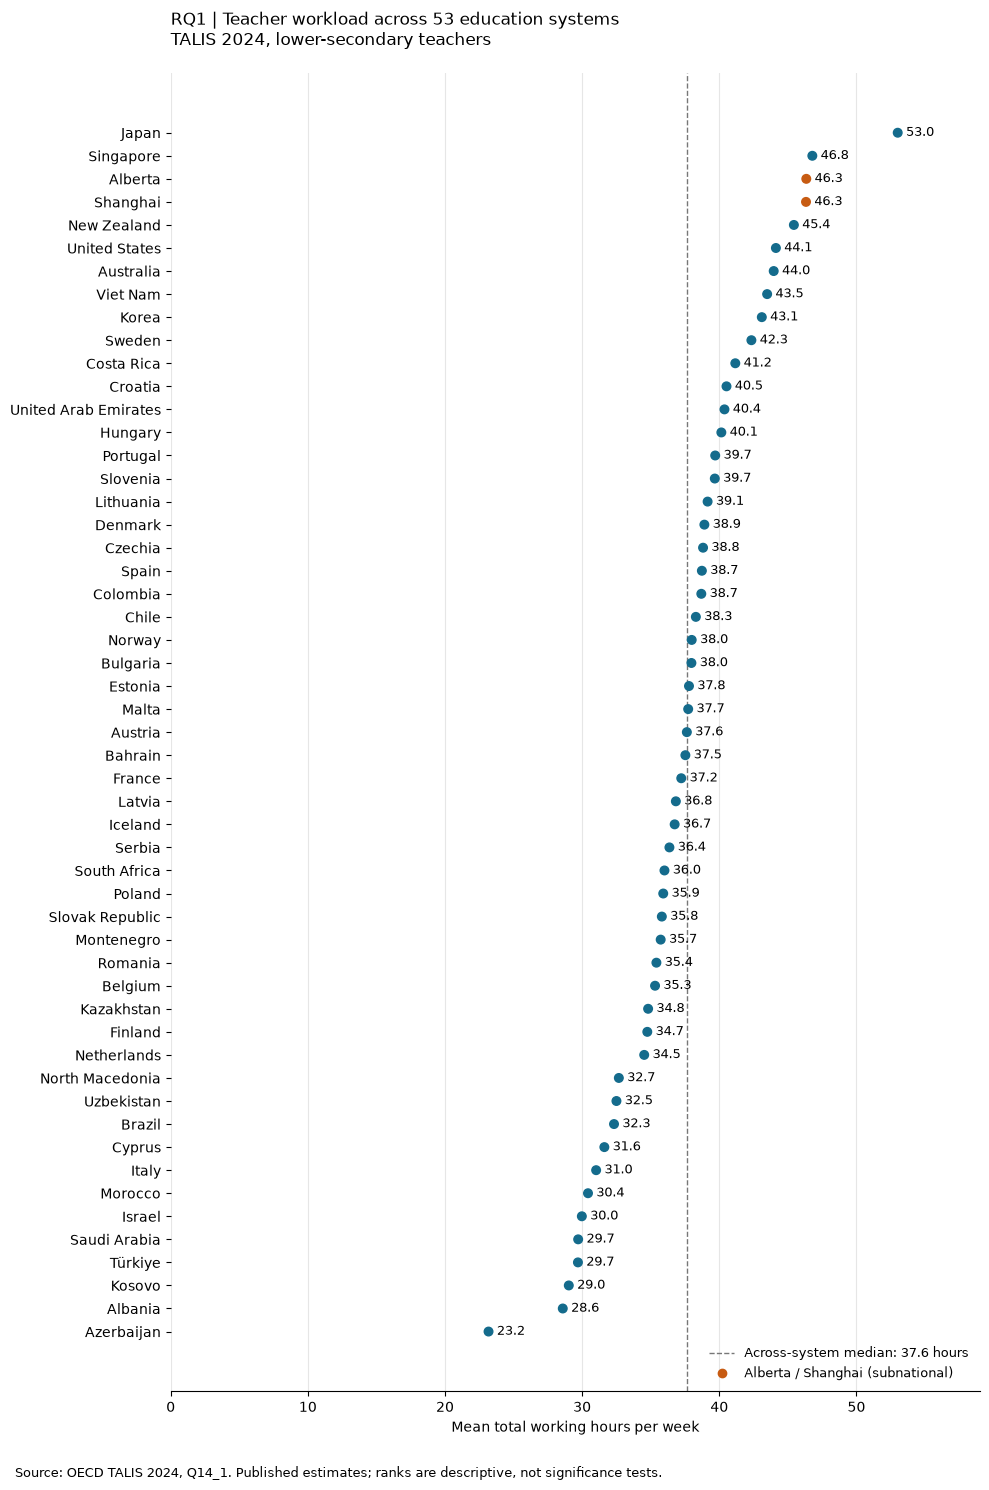

Highest: Japan (53.01 h); lowest: Azerbaijan (23.17 h).
Range: 29.84 hours; unweighted system median: 37.63 hours.


In [9]:
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

FIGURE_DIR = PROJECT_DIR / "deliverables" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

rq1 = rq_samples["RQ1"].sort_values("total_work_hours", ascending=False).copy()

assert rq1["REF_AREA"].is_unique

rq1_coverage = area_decisions.copy()

rq1_coverage = rq1_coverage.merge(

    analysis_table[["REF_AREA", "total_work_hours"]], on="REF_AREA", how="left", validate="one_to_one")

rq1_coverage["plotted"] = rq1_coverage["included"] & rq1_coverage["total_work_hours"].notna()

display(rq1_coverage.groupby(["included", "plotted"]).size().rename("systems").to_frame())

display(rq1_coverage.loc[~rq1_coverage["plotted"]])

display(rq1["total_work_hours"].describe().round(2).to_frame("Hours across systems"))

rq1_coverage.to_csv(PROCESSED_DIR / "rq1_coverage_audit.csv", index=False)

rq1[["REF_AREA", "area_name", "total_work_hours"]].to_csv(PROCESSED_DIR / "rq1_ranked_workload.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 15))

colours = ["#c75b12" if area in ["CA48", "CN09"] else "#146b8c" for area in rq1["REF_AREA"]]

ax.scatter(rq1["total_work_hours"], range(len(rq1)), c=colours, s=38, zorder=3)

ax.set_yticks(range(len(rq1)), rq1["area_name"])

ax.invert_yaxis()

ax.set_xlim(0, rq1["total_work_hours"].max() + 6)

for y, hours in enumerate(rq1["total_work_hours"]):

    ax.annotate(f"{hours:.1f}", (hours, y), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)

median_hours = rq1["total_work_hours"].median()

ax.axvline(median_hours, color="#777777", linestyle="--", linewidth=1,

           label=f"Across-system median: {median_hours:.1f} hours")

ax.set_xlabel("Mean total working hours per week")

ax.set_title(f"RQ1 | Teacher workload across {len(rq1)} education systems\nTALIS {YEAR}, lower-secondary teachers", loc="left", pad=20)

ax.grid(axis="x", color="#e6e6e6")

ax.set_axisbelow(True)

ax.spines[["top", "right", "left"]].set_visible(False)

handles, labels = ax.get_legend_handles_labels()

handles.append(Line2D([], [], color="#c75b12", marker="o", linestyle="", label="Alberta / Shanghai (subnational)"))

ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=9)

fig.text(0.02, 0.012, "Source: OECD TALIS 2024, Q14_1. Published estimates; ranks are descriptive, not significance tests.", fontsize=9)

fig.tight_layout(rect=(0, 0.03, 1, 1))

fig.savefig(FIGURE_DIR / "rq1_ranked_workload.png", dpi=180, bbox_inches="tight")

plt.show()

print(f"Highest: {rq1.iloc[0]['area_name']} ({rq1.iloc[0]['total_work_hours']:.2f} h); "

      f"lowest: {rq1.iloc[-1]['area_name']} ({rq1.iloc[-1]['total_work_hours']:.2f} h).")

print(f"Range: {rq1['total_work_hours'].max() - rq1['total_work_hours'].min():.2f} hours; "

      f"unweighted system median: {median_hours:.2f} hours.")


### RQ2: How does teaching time compare with non-teaching workload across education systems?


The 100% stacked bars in Figures 2a–c compare workload composition, rather than repeat RQ1's total-hours ranking. For each system, teaching share is mean teaching hours / mean total working hours × 100; estimated non-teaching share is (mean total − mean teaching hours) / mean total × 100. These are ratios of published system means, not the mean of individual teachers' time shares. Non-teaching time includes preparation, marking and other duties; it is not administrative time alone.

Rows run from the largest non-teaching share to the smallest, with alphabetical ties. Equal-length bars conceal total workload differences, so aligned hours columns retain the original scale. All 53 systems are included. Source: OECD TALIS 2024, lower-secondary teachers, Q14_1 and Q15_1 (saved extracts).

,REF_AREA,area_name,total_work_hours,teaching_hours,non_teaching_hours,teaching_share_pct,non_teaching_share_pct
0,JPN,Japan,53.01,17.39,35.62,32.81,67.19
1,SGP,Singapore,46.78,17.57,29.22,37.55,62.45
2,NOR,Norway,37.99,15.92,22.07,41.91,58.09
3,CN09,Shanghai,46.32,20.02,26.31,43.21,56.79
4,KOR,Korea,43.10,18.65,24.45,43.28,56.72
5,AUS,Australia,43.97,19.26,24.71,43.81,56.19
6,SWE,Sweden,42.34,18.56,23.78,43.84,56.16
7,NZL,New Zealand,45.44,20.83,24.60,45.85,54.15
8,NLD,Netherlands,34.52,16.16,18.37,46.80,53.20
9,PRT,Portugal,39.70,19.45,20.25,48.99,51.01


RQ2 systems: 53 | Excluded for missingness: 0


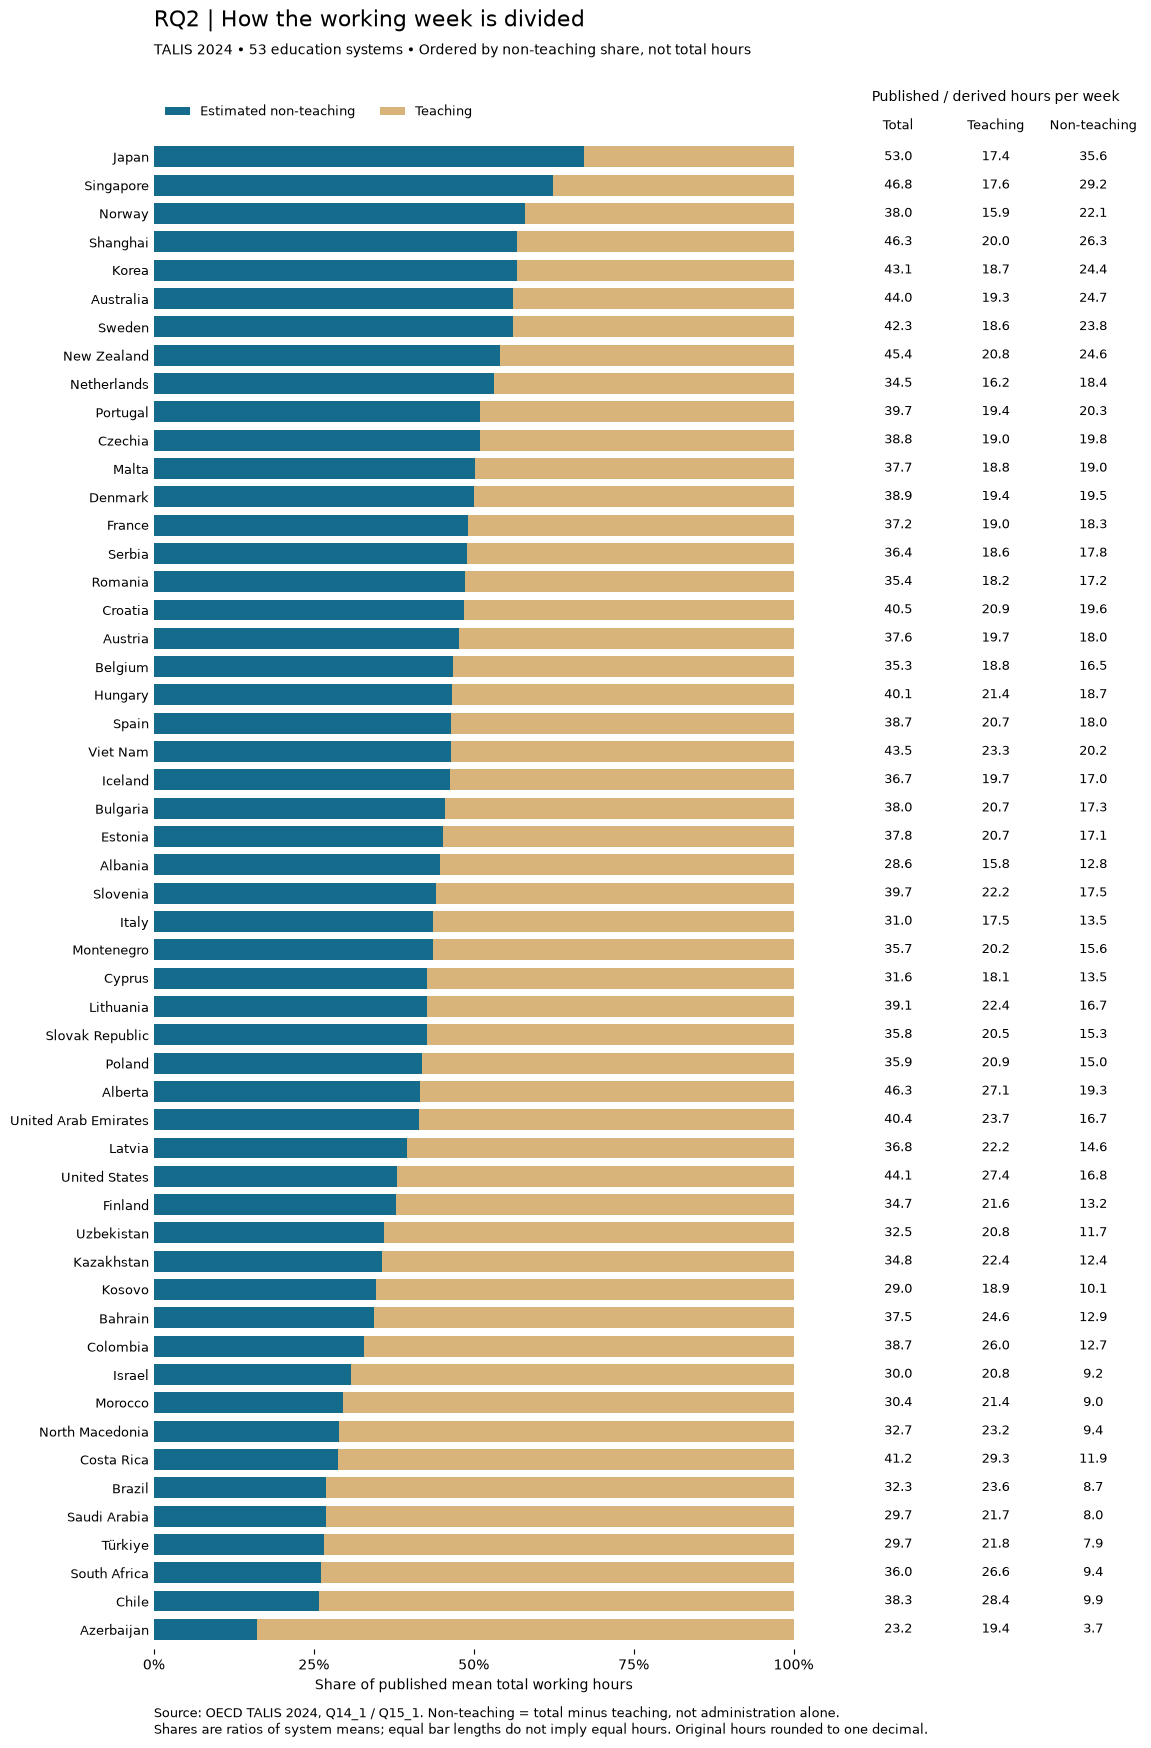

Non-teaching share: 16.11%–67.19%; unweighted system median 44.11%.


In [10]:
# Reuse the existing derived hours; validate the percentage denominator

rq2 = rq_samples["RQ2"].copy()

assert rq2["REF_AREA"].is_unique

assert rq2[["total_work_hours", "teaching_hours", "non_teaching_hours"]].notna().all().all()

assert rq2["total_work_hours"].gt(0).all()

rq2["teaching_share_pct"] = 100 * rq2["teaching_hours"] / rq2["total_work_hours"]

rq2["non_teaching_share_pct"] = 100 * rq2["non_teaching_hours"] / rq2["total_work_hours"]

assert (rq2["teaching_share_pct"] + rq2["non_teaching_share_pct"] - 100).abs().lt(1e-10).all()

rq2 = rq2.sort_values(["non_teaching_share_pct", "area_name"], ascending=[False, True]).reset_index(drop=True)

rq2_columns = ["REF_AREA", "area_name", "total_work_hours", "teaching_hours", "non_teaching_hours", "teaching_share_pct", "non_teaching_share_pct"]

rq2[rq2_columns].to_csv(PROCESSED_DIR / "rq2_workload_composition.csv", index=False)

with pd.option_context("display.max_rows", None, "display.max_columns", None):

    display(rq2[rq2_columns].round(2))

print("RQ2 systems:", len(rq2), "| Excluded for missingness:", len(analysis_table) - len(rq2))

fig, (ax, hours_ax) = plt.subplots(1, 2, figsize=(13, 18), sharey=True,

                                  gridspec_kw={"width_ratios": [3.5, 1.6], "wspace": 0.12})

rows = range(len(rq2))

ax.barh(rows, rq2["non_teaching_share_pct"], color="#146b8c", height=0.74, label="Estimated non-teaching")

ax.barh(rows, rq2["teaching_share_pct"], left=rq2["non_teaching_share_pct"],

        color="#d8b47a", height=0.74, label="Teaching")

ax.set_yticks(rows, rq2["area_name"], fontsize=9)

ax.set_ylim(len(rq2) - 0.3, -0.7)

ax.set_xlim(0, 100)

ax.set_xticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"])

ax.set_xlabel("Share of published mean total working hours")

ax.tick_params(axis="y", length=0)

ax.grid(False)

ax.legend(loc="lower left", bbox_to_anchor=(0, 1.005), frameon=False, ncol=2, fontsize=9)

# Original hours are aligned with every bar, not a second ranking

hours_ax.set_xlim(-0.5, 2.5)

hours_ax.set_xticks([0, 1, 2], ["Total", "Teaching", "Non-teaching"], fontsize=9)

hours_ax.xaxis.tick_top()

hours_ax.tick_params(axis="both", length=0, labelleft=False)

hours_ax.set_title("Published / derived hours per week", fontsize=10, pad=26)

for row in rows:

    for col, field in enumerate(["total_work_hours", "teaching_hours", "non_teaching_hours"]):

        hours_ax.text(col, row, f"{rq2.loc[row, field]:.1f}", ha="center", va="center", fontsize=9)

for panel_ax in (ax, hours_ax):

    for spine in panel_ax.spines.values():

        spine.set_visible(False)

fig.subplots_adjust(left=0.22, right=0.98, top=0.91, bottom=0.07)

fig.suptitle("RQ2 | How the working week is divided", x=0.22, ha="left", y=0.981, fontsize=16)

fig.text(0.22, 0.956, f"TALIS {YEAR} • {len(rq2)} education systems • Ordered by non-teaching share, not total hours", fontsize=10)

fig.text(0.22, 0.023, "Source: OECD TALIS 2024, Q14_1 / Q15_1. Non-teaching = total minus teaching, not administration alone.\nShares are ratios of system means; equal bar lengths do not imply equal hours. Original hours rounded to one decimal.", fontsize=9)

fig.savefig(FIGURE_DIR / "rq2_workload_composition.png", dpi=180, bbox_inches="tight")

plt.show()

print(f"Non-teaching share: {rq2['non_teaching_share_pct'].min():.2f}%–{rq2['non_teaching_share_pct'].max():.2f}%; "

      f"unweighted system median {rq2['non_teaching_share_pct'].median():.2f}%.")


Non-teaching time accounts for between 16.1% in Azerbaijan and 67.2% in Japan of published mean working hours. Azerbaijan reports 19.4 teaching hours and 3.7 derived non-teaching hours within a 23.2-hour week; Japan reports 17.4 teaching and 35.6 non-teaching hours within a 53.0-hour week. Similar classroom hours can therefore sit within very different overall workloads. Rounding means displayed components may not sum exactly.

The unweighted median non-teaching share across systems is 44.1%; non-teaching hours exceed teaching hours in 13 of 53 systems. The composition view shows the balance that a total-hours ranking alone misses, while the hours columns prevent a large percentage being mistaken for a large absolute workload.

### RQ3: Which education systems show the strongest administrative-stress burden, and how is that pattern distributed geographically?


High administrative stress is the percentage answering “Quite a bit” + “A lot” to Q77_B, already calculated in pre-processing. Following the ordered-colour principle discussed by Harrower and Brewer (2003), a sequential 0–100% colour scale in Figure 3a shows the geographical distribution of published estimates, not numbers of teachers or statistical significance. Grey means no national value mapped, not zero stress.

Natural Earth 1:50 million Admin-0 countries provide supporting cartographic geometry, not another substantive outcome dataset. Its public-domain licence and the boundary ZIP are saved with the project. The map is reprojected from WGS84 to Equal Earth (EPSG:8857) to preserve relative areas, rather than using unprojected longitude/latitude. Generalised boundaries establish neither exact survey coverage nor a position on disputed territories.

The identifier audit below uses Natural Earth ADM0_A3, with an explicit XKV → KOS correspondence for Kosovo. Alberta and Shanghai appear only in a separate dot panel (Figure 3b): their estimates never colour Canada or China. Belgium's retained national-labelled estimate is also kept in that panel rather than assuming complete territorial coverage from its code; the Flemish and French Community rows remain excluded as overlapping observations. Cyprus is panel-only because survey/boundary territorial equivalence has not been established. Bahrain, Malta and Singapore use the same panel for legibility at world scale. These are display decisions, not exclusions from the stress comparison. Other system identifiers are checked against the boundary table, without claiming exact sampling coverage.

Portugal has the highest administrative-stress share (79.3%), followed by Belgium (70.3%) and Australia (69.0%); Morocco (24.6%) and Kazakhstan (25.4%) are lowest. High values are geographically dispersed: South Africa records 66.1% and Costa Rica 65.2%. Europe is not uniform, with Portugal at 79.3% but Iceland at 31.3%. Japan (62.8%) also contrasts with panel-only Shanghai (29.2%). The map therefore shows within-region contrasts as well as distant high-stress systems, not a single regional pattern. It cannot identify regional causes; uneven participation and land-area prominence constrain geographical interpretation.

,REF_AREA,area_name,admin_stress_high_pct,ADM0_A3,boundary_matched,display_decision,value_available
0,ALB,Albania,31.240387,ALB,True,National outline: identifier checked,True
1,CA48,Alberta,38.868077,NaN,False,Alberta only; not Canada,True
2,AUS,Australia,69.016179,AUS,True,National outline: identifier checked,True
3,AUT,Austria,56.567913,AUT,True,National outline: identifier checked,True
4,AZE,Azerbaijan,30.192566,AZE,True,National outline: identifier checked,True
5,BHR,Bahrain,44.733131,NaN,False,Small system: panel for legibility,True
6,BEL,Belgium,70.322482,NaN,False,National-labelled estimate; community coverage...,True
7,BRA,Brazil,54.350391,BRA,True,National outline: identifier checked,True
8,BGR,Bulgaria,35.575607,BGR,True,National outline: identifier checked,True
9,CHL,Chile,56.879278,CHL,True,National outline: identifier checked,True


Boundary CRS: EPSG:4326 | valid geometries: 242
Mapped national estimates: 46 | separate-panel estimates: 7 | missing stress estimates: 0


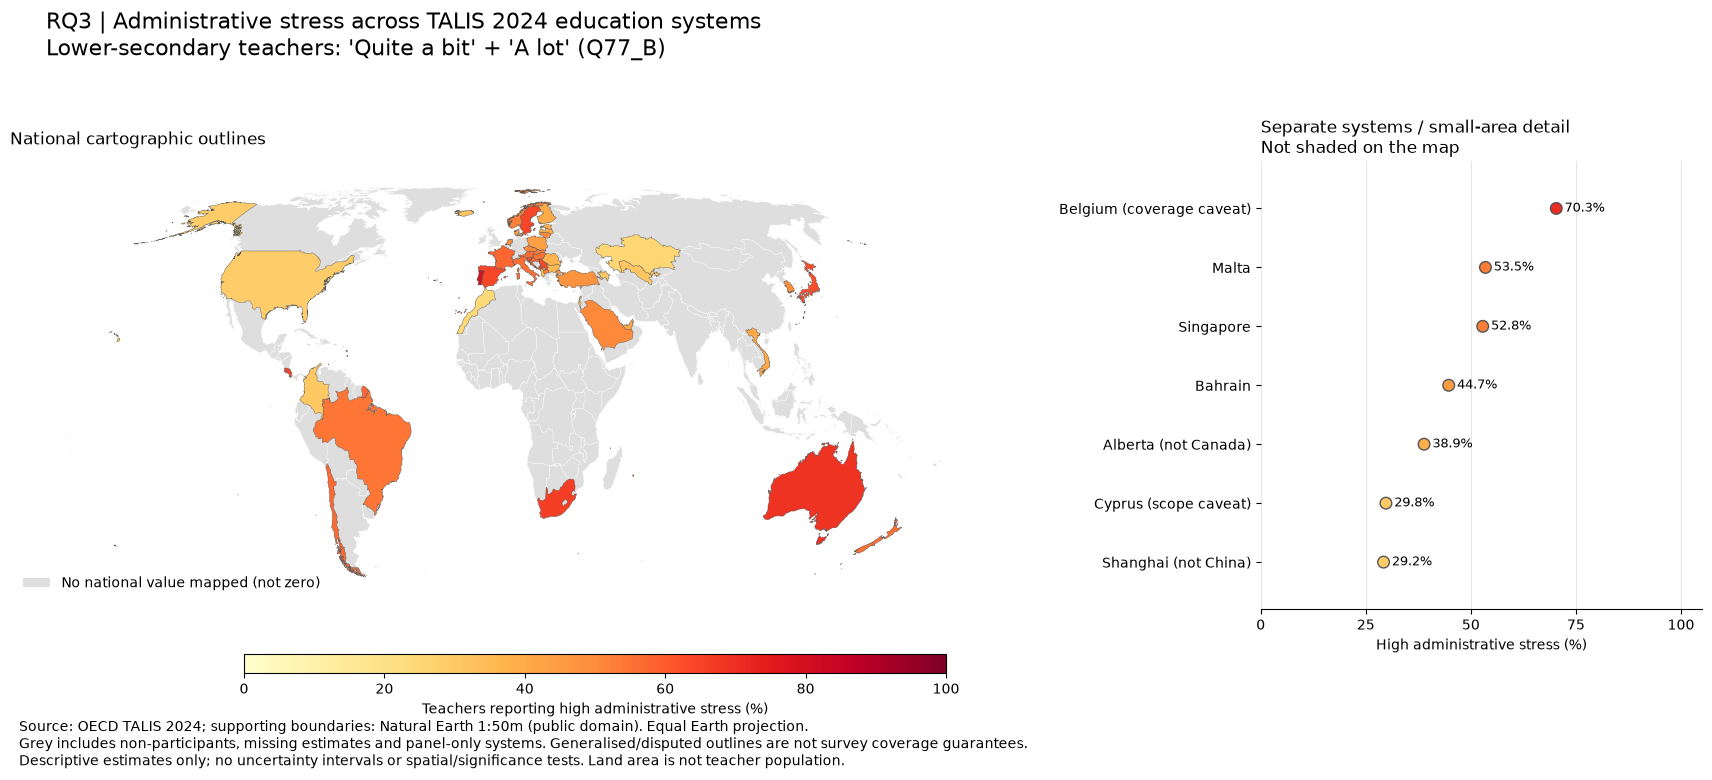

,area_name,admin_stress_high_pct
37,Portugal,79.27
6,Belgium,70.32
2,Australia,69.02
30,Montenegro,66.26
45,South Africa,66.12


,area_name,admin_stress_high_pct
41,Shanghai,29.23
50,United States,28.91
21,Israel,28.36
24,Kazakhstan,25.40
31,Morocco,24.64


Across-system median: 50.63%; range: 24.64–79.27%.


In [11]:
import geopandas as gpd

from matplotlib.colors import Normalize

from matplotlib.cm import ScalarMappable

from matplotlib.patches import Patch

boundaries = gpd.read_file(PROJECT_DIR / "data" / "boundaries" / "ne_50m_admin_0_countries.zip")

assert boundaries.crs.to_epsg() == 4326

assert boundaries["ADM0_A3"].is_unique

assert boundaries.geometry.notna().all() and (~boundaries.geometry.is_empty).all()

assert boundaries.geometry.is_valid.all(), "Investigate invalid boundary geometry"

# Explicitly reviewed national cartographic identifiers (not a code-length filter).

national_ids = [

    "ALB", "ARE", "AUS", "AUT", "AZE", "BGR", "BRA", "CHL", "COL", "CRI",

    "CZE", "DNK", "ESP", "EST", "FIN", "FRA", "HRV", "HUN", "ISL", "ISR",

    "ITA", "JPN", "KAZ", "KOR", "LTU", "LVA", "MAR", "MKD", "MNE", "NLD",

    "NOR", "NZL", "POL", "PRT", "ROU", "SAU", "SRB", "SVK", "SVN", "SWE",

    "TUR", "USA", "UZB", "VNM", "ZAF"

]

map_ids = {area: area for area in national_ids}

map_ids["XKV"] = "KOS"

panel_reasons = {

    "CA48": "Alberta only; not Canada", "CN09": "Shanghai only; not China",

    "BEL": "National-labelled estimate; community coverage not mapped",

    "CYP": "Territorial equivalence not established; panel only",

    "BHR": "Small system: panel for legibility", "MLT": "Small system: panel for legibility",

    "SGP": "Small system: panel for legibility"

}

rq3_audit = analysis_table[["REF_AREA", "area_name", "admin_stress_high_pct"]].copy()

assert set(rq3_audit["REF_AREA"]) == set(map_ids) | set(panel_reasons), "New system: review geography first"

rq3_audit["ADM0_A3"] = rq3_audit["REF_AREA"].map(map_ids)

rq3_audit["boundary_matched"] = rq3_audit["ADM0_A3"].isin(boundaries["ADM0_A3"])

rq3_audit["display_decision"] = rq3_audit["REF_AREA"].map(panel_reasons).fillna("National outline: identifier checked")

rq3_audit["value_available"] = rq3_audit["admin_stress_high_pct"].notna()

assert rq3_audit.loc[rq3_audit["REF_AREA"].isin(map_ids), "boundary_matched"].all()

assert not rq3_audit.loc[rq3_audit["REF_AREA"].isin(panel_reasons), "boundary_matched"].any()

map_values = rq3_audit.loc[rq3_audit["boundary_matched"]].copy()

world = boundaries.loc[boundaries["ADM0_A3"] != "ATA", ["ADM0_A3", "ADMIN", "geometry"]].merge(

    map_values[["ADM0_A3", "REF_AREA", "admin_stress_high_pct"]], on="ADM0_A3", how="left", validate="one_to_one")

assert world.loc[world["ADM0_A3"].isin(["CAN", "CHN", "BEL", "CYP", "CYN"]), "admin_stress_high_pct"].isna().all()

world["mapped_value"] = world["admin_stress_high_pct"].notna()

rq3_audit.to_csv(PROCESSED_DIR / "rq3_system_boundary_audit.csv", index=False)

world.drop(columns="geometry").to_csv(PROCESSED_DIR / "rq3_boundary_coverage_audit.csv", index=False)

display(rq3_audit)

print("Boundary CRS:", boundaries.crs, "| valid geometries:", int(boundaries.geometry.is_valid.sum()))

print("Mapped national estimates:", int(world["mapped_value"].sum()),

      "| separate-panel estimates:", int(rq3_audit.loc[rq3_audit["REF_AREA"].isin(panel_reasons), "value_available"].sum()),

      "| missing stress estimates:", int((~rq3_audit["value_available"]).sum()))

panel = rq3_audit.loc[rq3_audit["REF_AREA"].isin(panel_reasons) & rq3_audit["value_available"]].sort_values("admin_stress_high_pct")

panel_labels = {"CA48": "Alberta (not Canada)", "CN09": "Shanghai (not China)",

                "BEL": "Belgium (coverage caveat)", "CYP": "Cyprus (scope caveat)"}

projected = world.to_crs(epsg=8857)

fig, (ax_map, ax_panel) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [3, 1.35]})

projected.plot(ax=ax_map, color="#dedede", edgecolor="white", linewidth=0.25)

projected.loc[projected["mapped_value"]].plot(

    column="admin_stress_high_pct", ax=ax_map, cmap="YlOrRd", vmin=0, vmax=100,

    edgecolor="#555555", linewidth=0.3)

ax_map.set_axis_off()

ax_map.set_title("National cartographic outlines", loc="left", fontsize=12)

ax_map.legend(handles=[Patch(facecolor="#dedede", label="No national value mapped (not zero)")],

              loc="lower left", frameon=False, fontsize=10)

ax_panel.scatter(panel["admin_stress_high_pct"], range(len(panel)),

                 c=panel["admin_stress_high_pct"], cmap="YlOrRd", vmin=0, vmax=100,

                 edgecolors="#555555", s=70, zorder=3)

ax_panel.set_yticks(range(len(panel)), [panel_labels.get(row.REF_AREA, row.area_name) for row in panel.itertuples()])

ax_panel.set_xlim(0, 105)

ax_panel.set_ylim(-0.8, len(panel) - 0.2)

ax_panel.set_xticks([0, 25, 50, 75, 100])

for y, value in enumerate(panel["admin_stress_high_pct"]):

    ax_panel.annotate(f"{value:.1f}%", (value, y), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)

ax_panel.set_xlabel("High administrative stress (%)")

ax_panel.set_title("Separate systems / small-area detail\nNot shaded on the map", loc="left", fontsize=12)

ax_panel.grid(axis="x", color="#e5e5e5")

ax_panel.spines[["top", "right", "left"]].set_visible(False)

fig.suptitle(f"RQ3 | Administrative stress across TALIS {YEAR} education systems\nLower-secondary teachers: 'Quite a bit' + 'A lot' (Q77_B)", fontsize=16, x=0.04, ha="left")

fig.subplots_adjust(left=0.02, right=0.96, top=0.79, bottom=0.23, wspace=0.38)

colour_ax = fig.add_axes([0.15, 0.15, 0.39, 0.024])

fig.colorbar(ScalarMappable(norm=Normalize(0, 100), cmap="YlOrRd"), cax=colour_ax,

             orientation="horizontal", label="Teachers reporting high administrative stress (%)")

fig.text(0.025, 0.035, "Source: OECD TALIS 2024; supporting boundaries: Natural Earth 1:50m (public domain). Equal Earth projection.\nGrey includes non-participants, missing estimates and panel-only systems. Generalised/disputed outlines are not survey coverage guarantees.\nDescriptive estimates only; no uncertainty intervals or spatial/significance tests. Land area is not teacher population.", fontsize=10)

fig.savefig(FIGURE_DIR / "rq3_administrative_stress_map.png", dpi=180, bbox_inches="tight")

plt.show()

rq3_ranked = rq_samples["RQ3"].sort_values("admin_stress_high_pct", ascending=False)

rq3_ranked[["REF_AREA", "area_name", "admin_stress_high_pct"]].to_csv(PROCESSED_DIR / "rq3_ranked_stress.csv", index=False)

display(rq3_ranked[["area_name", "admin_stress_high_pct"]].head(5).round(2))

display(rq3_ranked[["area_name", "admin_stress_high_pct"]].tail(5).round(2))

print(f"Across-system median: {rq3_ranked['admin_stress_high_pct'].median():.2f}%; "

      f"range: {rq3_ranked['admin_stress_high_pct'].min():.2f}–{rq3_ranked['admin_stress_high_pct'].max():.2f}%.")


### RQ4: To what extent does greater non-teaching workload coincide with stronger administrative stress across education systems in TALIS, and which education systems stand out as notable outliers?


The scatter plot in Figure 4 follows Topic 5's relationship-and-correlation approach: each point is one education system, given equal weight. Pearson's r summarises linear association between estimated non-teaching hours and high administrative stress (‘Quite a bit’ + ‘A lot’ to Q77_B). All 53 complete systems remain in the comparison.

To identify notable departures reproducibly, a simple descriptive least-squares line is drawn: slope = covariance(hours, stress) / variance(hours), with the intercept chosen so the line passes through the two means. A residual is observed stress minus fitted stress, measured in percentage points. The four largest absolute residuals are labelled, with alphabetical tie-breaking. Four is a readability limit, not an outlier threshold; the full ranked table is exported. The minimum- and maximum-hours systems are labelled separately as x-extremes. Thus ‘outliers’ here means notable descriptive cases, not a formal classification. No observations are deleted or inferential outlier tests performed. Source: OECD TALIS 2024, Q14_1, Q15_1 and Q77_B (saved extracts).

,systems,pearson_r,slope_pp_per_hour,intercept_pct,excluded_for_missingness
0,53,0.309,0.71,36.633,0


,REF_AREA,area_name,non_teaching_hours,admin_stress_high_pct,fitted_stress_pct,residual_pp,absolute_residual_pp,absolute_residual_rank,label_residual,label_x_extreme
0,PRT,Portugal,20.25,79.27,51.02,28.25,28.25,1,True,False
1,CN09,Shanghai,26.31,29.23,55.31,-26.09,26.09,2,True,False
2,ZAF,South Africa,9.39,66.12,43.30,22.82,22.82,3,True,False
3,BEL,Belgium,16.53,70.32,48.37,21.95,21.95,4,True,False
29,AZE,Azerbaijan,3.73,30.19,39.28,-9.09,9.09,30,False,True
49,JPN,Japan,35.62,62.82,61.92,0.90,0.90,50,False,True


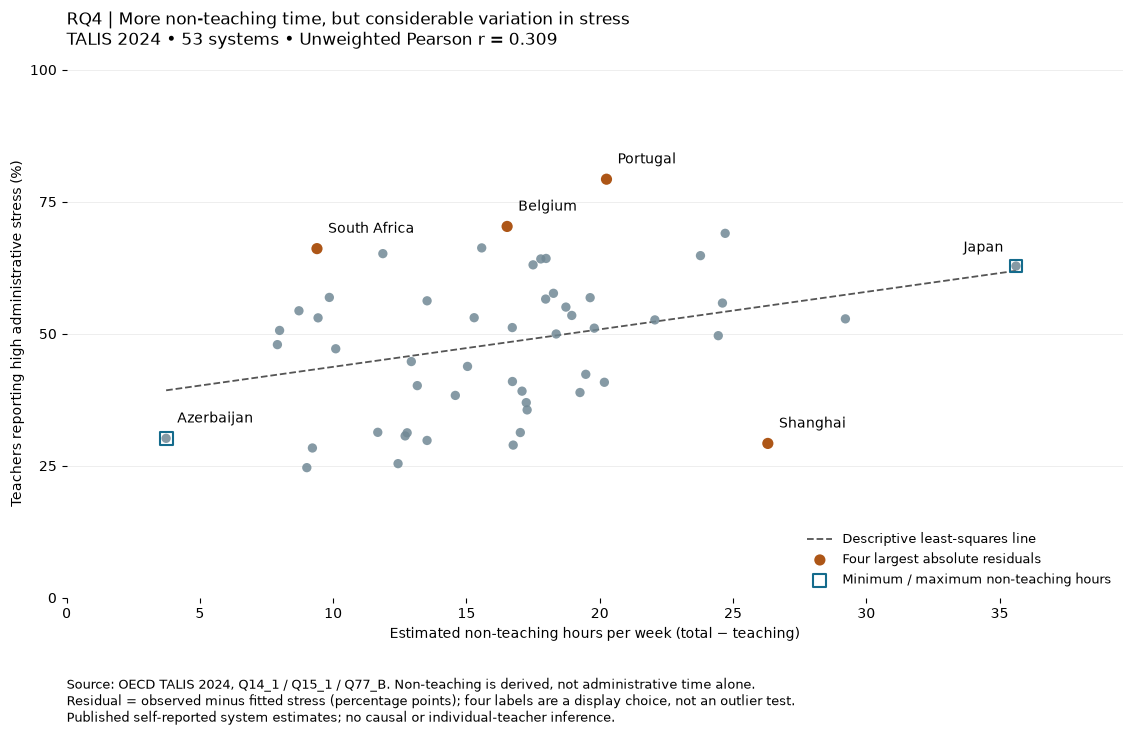

In [12]:
rq4 = rq_samples["RQ4"][["REF_AREA", "area_name", "non_teaching_hours", "admin_stress_high_pct"]].copy()

assert rq4["REF_AREA"].is_unique

x = rq4["non_teaching_hours"]

y = rq4["admin_stress_high_pct"]

assert x.var() > 0 and y.var() > 0

rq4_r = x.corr(y)

rq4_slope = x.cov(y) / x.var()

rq4_intercept = y.mean() - rq4_slope * x.mean()

rq4["fitted_stress_pct"] = rq4_intercept + rq4_slope * x

rq4["residual_pp"] = y - rq4["fitted_stress_pct"]

rq4["absolute_residual_pp"] = rq4["residual_pp"].abs()

rq4 = rq4.sort_values(["absolute_residual_pp", "area_name"], ascending=[False, True]).reset_index(drop=True)

rq4["absolute_residual_rank"] = range(1, len(rq4) + 1)

rq4["label_residual"] = rq4["absolute_residual_rank"].le(4)

rq4["label_x_extreme"] = rq4["non_teaching_hours"].isin([x.min(), x.max()])

rq4.to_csv(PROCESSED_DIR / "rq4_descriptive_residuals.csv", index=False)

rq4_summary = pd.DataFrame([{"systems": len(rq4), "pearson_r": rq4_r,

                             "slope_pp_per_hour": rq4_slope, "intercept_pct": rq4_intercept,

                             "excluded_for_missingness": len(analysis_table) - len(rq4)}])

rq4_summary.to_csv(PROCESSED_DIR / "rq4_correlation_summary.csv", index=False)

display(rq4_summary.round(3))

display(rq4.loc[rq4["label_residual"] | rq4["label_x_extreme"]].round(2))

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(x, y, s=45, color="#718995", alpha=0.85, edgecolors="none", zorder=3)

line_x = pd.Series([x.min(), x.max()])

ax.plot(line_x, rq4_intercept + rq4_slope * line_x, color="#555555", linestyle="--",

        linewidth=1.3, label="Descriptive least-squares line")

selected = rq4.loc[rq4["label_residual"]]

extremes = rq4.loc[rq4["label_x_extreme"]]

ax.scatter(selected["non_teaching_hours"], selected["admin_stress_high_pct"], s=65,

           color="#ad5617", edgecolors="none", zorder=4, label="Four largest absolute residuals")

ax.scatter(extremes["non_teaching_hours"], extremes["admin_stress_high_pct"], s=85,

           marker="s", facecolors="none", edgecolors="#146b8c", linewidths=1.5, zorder=5,

           label="Minimum / maximum non-teaching hours")

for row in rq4.loc[rq4["label_residual"] | rq4["label_x_extreme"]].itertuples():

    # Offsets affect text placement only, never selection or values.

    offset = (-9, 8) if row.non_teaching_hours == x.max() else (8, 9)

    ax.annotate(row.area_name, (row.non_teaching_hours, row.admin_stress_high_pct),

                xytext=offset, textcoords="offset points", fontsize=10,

                ha="right" if offset[0] < 0 else "left", va="bottom")

ax.set_xlim(0, x.max() + 4)

ax.set_ylim(0, 100)

ax.set_yticks([0, 25, 50, 75, 100])

ax.set_xlabel("Estimated non-teaching hours per week (total − teaching)")

ax.set_ylabel("Teachers reporting high administrative stress (%)")

ax.set_title(f"RQ4 | More non-teaching time, but considerable variation in stress\nTALIS {YEAR} • {len(rq4)} systems • Unweighted Pearson r = {rq4_r:.3f}", loc="left", pad=18)

ax.grid(axis="y", color="#eeeeee", linewidth=0.7)

ax.set_axisbelow(True)

for spine in ax.spines.values():

    spine.set_visible(False)

ax.legend(loc="lower right", frameon=False, fontsize=9)

fig.subplots_adjust(left=0.09, right=0.97, top=0.85, bottom=0.19)

fig.text(0.09, 0.035, "Source: OECD TALIS 2024, Q14_1 / Q15_1 / Q77_B. Non-teaching is derived, not administrative time alone.\nResidual = observed minus fitted stress (percentage points); four labels are a display choice, not an outlier test.\nPublished self-reported system estimates; no causal or individual-teacher inference.", fontsize=9)

fig.savefig(FIGURE_DIR / "rq4_non_teaching_stress_scatter.png", dpi=180, bbox_inches="tight")

plt.show()


Across the 53 systems, greater non-teaching workload coincides with higher administrative stress to a limited extent: Pearson r = 0.309. The upward trend is accompanied by substantial vertical spread, so non-teaching time alone does not closely track the stress percentage. The descriptive line rises by about 0.71 percentage points per additional hour; this is an across-system summary, not an estimated effect of changing a teacher's workload.

The largest absolute departures are Portugal (+28.3 percentage points), Shanghai (−26.1), South Africa (+22.8) and Belgium (+22.0) relative to the line. Portugal reports 79.3% stress at 20.3 non-teaching hours, whereas Shanghai reports 29.2% at 26.3 hours. These stress percentages are higher or lower than the fitted value at their workload, not automatically erroneous observations. Belgium retains the coverage caveat noted in pre-processing and RQ3. Japan (35.6 hours) and Azerbaijan (3.7 hours) mark the workload extremes; neither belongs to the four largest absolute residuals.

The scatter and labelled cases qualify the correlation: non-teaching time covers more than administration, and the line and residual ranking depend on the systems included. More task-specific data would be needed to investigate the contrast between Portugal and Shanghai.

### RQ5: How do workload–stress profiles compare across education systems, and how do they relate to teachers’ willingness to recommend their school?


The heatmap in Figures 5a–c compares the three workload–stress indicators together rather than assigning systems to clusters. Teaching and estimated non-teaching hours represent workload composition; administrative stress represents reported pressure. Total hours are not an extra axis because they equal the sum of the two time components. Recommendation is a separate outcome, never an input to the profiles or row order.

Following Topic 9's multidimensional heatmap approach, each profile feature is explicitly min–max normalised: (value − feature minimum) / (feature maximum − feature minimum) across the included systems. This allows hours and percentages to be shown on one relative colour scale without equating their units. The original ranges are shown above the columns, and every tile carries its original value. The original numeric table and a separate normalised table are exported below.

Rows are ordered by administrative stress descending, with alphabetical tie-breaking. Darker profile tiles mean a higher value within that feature's observed range, not a policy threshold or a good/bad rating. Recommendation is plotted alongside on its own absolute 0–100% axis: ‘Agree’ + ‘Strongly agree’ to recommending the school as a good place to work.

,minimum,maximum,unit
teaching_hours,15.81,29.30,hours/week
non_teaching_hours,3.73,35.62,hours/week
admin_stress_high_pct,24.64,79.27,% of teachers


RQ5 profile systems: 53 | Available recommendation outcomes: 53


,REF_AREA,area_name,TIME_PERIOD,teaching_hours,non_teaching_hours,admin_stress_high_pct,school_recommend_positive_pct
0,PRT,Portugal,2024,19.45,20.25,79.27,89.50
1,BEL,Belgium,2024,18.79,16.53,70.32,84.94
2,AUS,Australia,2024,19.26,24.71,69.02,82.91
3,MNE,Montenegro,2024,20.15,15.57,66.26,87.52
4,ZAF,South Africa,2024,26.61,9.39,66.12,72.40
5,CRI,Costa Rica,2024,29.30,11.86,65.17,80.45
6,SWE,Sweden,2024,18.56,23.78,64.79,84.00
7,ESP,Spain,2024,20.74,17.99,64.26,86.03
8,SRB,Serbia,2024,18.57,17.79,64.17,84.85
9,SVN,Slovenia,2024,22.17,17.50,63.05,80.54


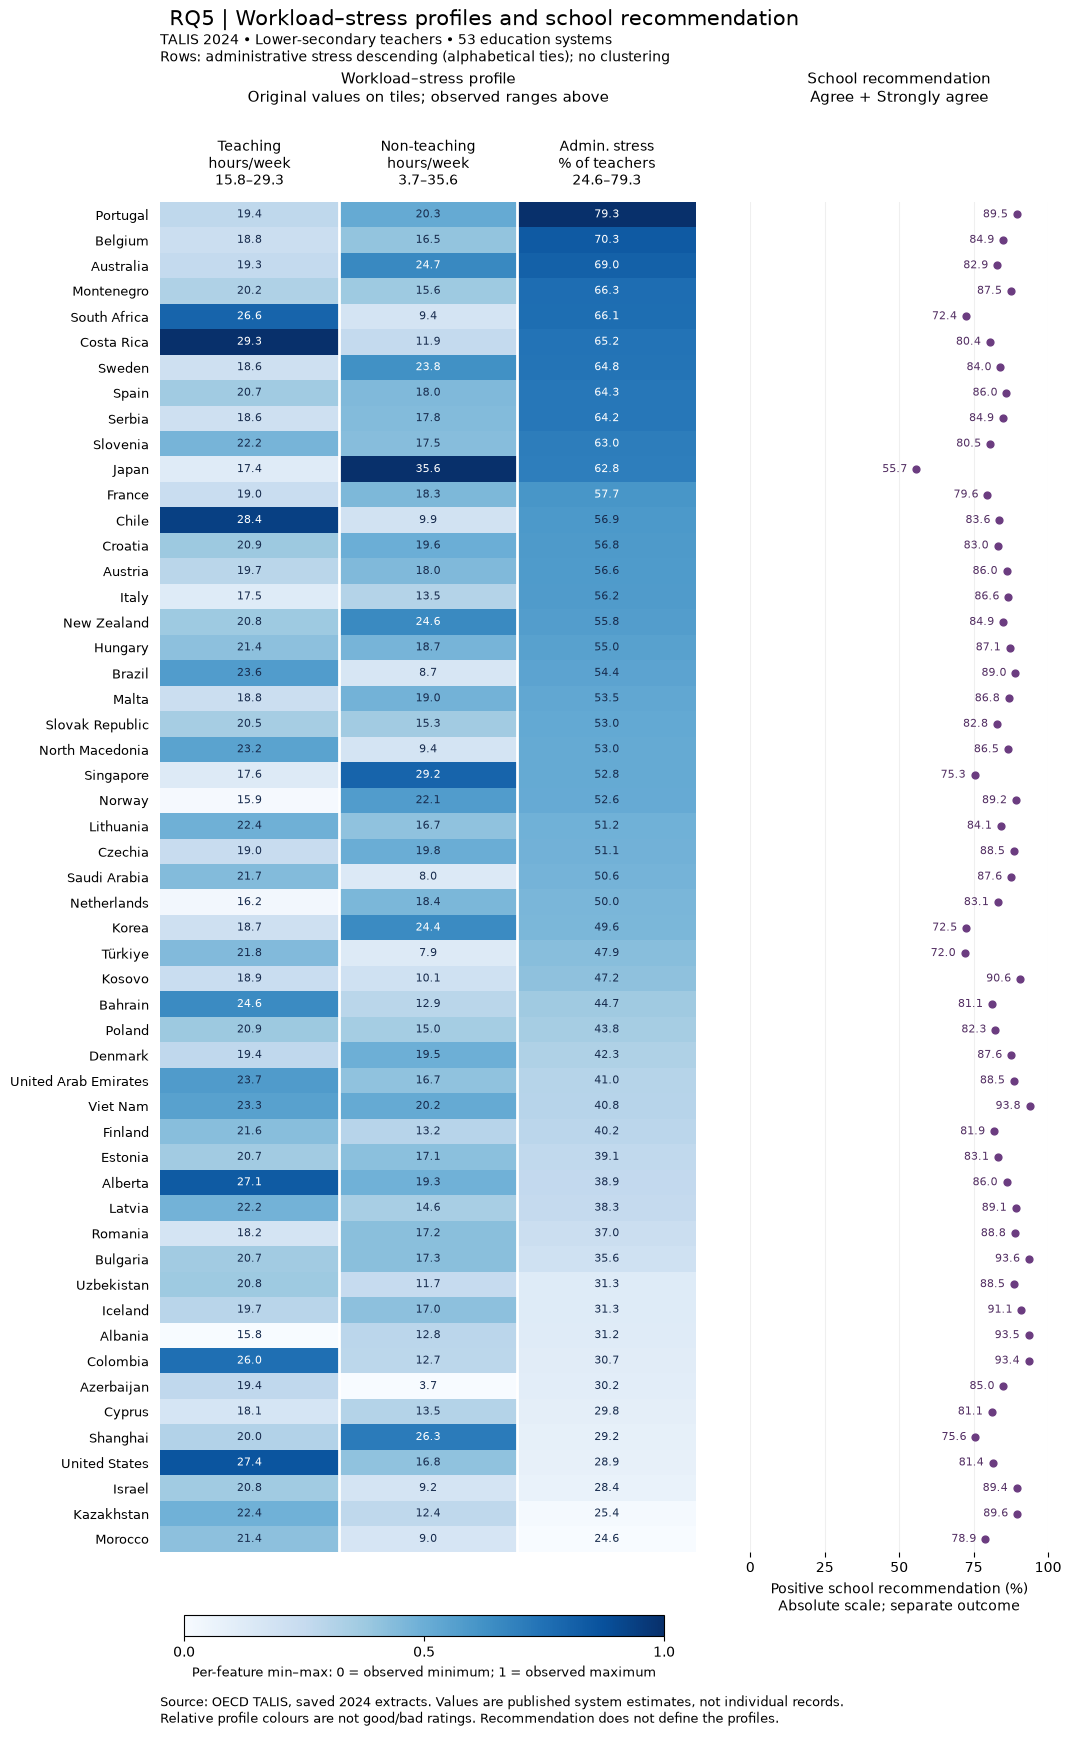

,Pearson r with recommendation (unweighted systems)
teaching_hours,0.014
non_teaching_hours,-0.365
admin_stress_high_pct,-0.243


In [13]:
# Reuse the exact indicators and RQ-specific sample from pre-processing

profile_features = ["teaching_hours", "non_teaching_hours", "admin_stress_high_pct"]

outcome = "school_recommend_positive_pct"

rq5 = rq_samples["RQ5_profiles"].sort_values(

    ["admin_stress_high_pct", "area_name"], ascending=[False, True]

).reset_index(drop=True)

# Explicit per-feature min–max scaling; recommendation is not normalised

profile_min = rq5[profile_features].min()

profile_max = rq5[profile_features].max()

profile_scaled = rq5[profile_features].copy()

for feature in profile_features:

    feature_range = profile_max[feature] - profile_min[feature]

    if feature_range == 0:

        profile_scaled[feature] = 0.5

        print(feature, "is constant: midpoint colour means no variation.")

    else:

        profile_scaled[feature] = (rq5[feature] - profile_min[feature]) / feature_range

assert profile_scaled.ge(0).all().all() and profile_scaled.le(1).all().all()

range_table = pd.DataFrame({"minimum": profile_min, "maximum": profile_max})

range_table["unit"] = ["hours/week", "hours/week", "% of teachers"]

display(range_table.round(2))

print("RQ5 profile systems:", len(rq5), "| Available recommendation outcomes:", rq5[outcome].notna().sum())

# Original-unit values remain available, including the unrounded CSV

original_columns = ["REF_AREA", "area_name", "TIME_PERIOD"] + profile_features + [outcome]

with pd.option_context("display.max_rows", None, "display.max_columns", None):

    display(rq5[original_columns].round(2))

rq5[original_columns].to_csv(PROCESSED_DIR / "rq5_original_profiles.csv", index=False)

scaled_export = rq5[["REF_AREA", "area_name"]].join(profile_scaled)

scaled_export.to_csv(PROCESSED_DIR / "rq5_minmax_profiles.csv", index=False)

range_table.to_csv(PROCESSED_DIR / "rq5_feature_ranges.csv", index_label="feature")

# A shared row axis aligns the relative profile with the separate outcome

fig, (profile_ax, outcome_ax) = plt.subplots(

    1, 2, figsize=(12, 18), sharey=True,

    gridspec_kw={"width_ratios": [3.6, 2], "wspace": 0.13}

)

image = profile_ax.imshow(profile_scaled, cmap="Blues", vmin=0, vmax=1, aspect="auto")

labels = ["Teaching\nhours/week", "Non-teaching\nhours/week", "Admin. stress\n% of teachers"]

column_labels = [f"{label}\n{profile_min[feature]:.1f}–{profile_max[feature]:.1f}"

                 for label, feature in zip(labels, profile_features)]

profile_ax.set_xticks(range(3), column_labels, fontsize=10)

profile_ax.xaxis.tick_top()

profile_ax.tick_params(axis="x", length=0, pad=9)

profile_ax.set_yticks(range(len(rq5)), rq5["area_name"], fontsize=9)

profile_ax.tick_params(axis="y", length=0, pad=8)

for row in range(len(rq5)):

    for col, feature in enumerate(profile_features):

        profile_ax.text(col, row, f"{rq5.loc[row, feature]:.1f}", ha="center", va="center",

                        fontsize=8, color="white" if profile_scaled.loc[row, feature] > 0.6 else "#172b4d")

# The 0.6 switch above controls text contrast only, not an analytical category

profile_ax.set_xticks([0.5, 1.5], minor=True)

profile_ax.grid(which="minor", axis="x", color="white", linewidth=2)

profile_ax.tick_params(which="minor", bottom=False, top=False)

profile_ax.set_title("Workload–stress profile\nOriginal values on tiles; observed ranges above", fontsize=11, pad=72)

rows = range(len(rq5))

outcome_ax.scatter(rq5[outcome], rows, color="#6b3c80", s=24, zorder=3)

for row in rows:

    value = rq5.loc[row, outcome]

    if pd.notna(value):

        outcome_ax.text(value - 3, row, f"{value:.1f}", ha="right", va="center", fontsize=8, color="#532f63")

    else:

        outcome_ax.text(50, row, "Missing", ha="center", va="center", fontsize=8)

outcome_ax.set_xlim(0, 100)

outcome_ax.set_xticks([0, 25, 50, 75, 100])

outcome_ax.set_xlabel("Positive school recommendation (%)\nAbsolute scale; separate outcome", fontsize=10)

outcome_ax.tick_params(axis="y", left=False, labelleft=False)

outcome_ax.grid(axis="x", alpha=0.2)

outcome_ax.set_title("School recommendation\nAgree + Strongly agree", fontsize=11, pad=72)

for ax in (profile_ax, outcome_ax):

    for spine in ax.spines.values():

        spine.set_visible(False)

fig.subplots_adjust(left=0.23, right=0.97, top=0.87, bottom=0.12)

colour_ax = fig.add_axes([0.25, 0.073, 0.40, 0.012])

colourbar = fig.colorbar(image, cax=colour_ax, orientation="horizontal", ticks=[0, 0.5, 1])

colourbar.set_label("Per-feature min–max: 0 = observed minimum; 1 = observed maximum", fontsize=9)

fig.suptitle("RQ5 | Workload–stress profiles and school recommendation", fontsize=15, y=0.977)

fig.text(0.23, 0.948, f"TALIS 2024 • Lower-secondary teachers • {len(rq5)} education systems\nRows: administrative stress descending (alphabetical ties); no clustering", fontsize=10)

fig.text(0.23, 0.025, "Source: OECD TALIS, saved 2024 extracts. Values are published system estimates, not individual records.\nRelative profile colours are not good/bad ratings. Recommendation does not define the profiles.", fontsize=9)

fig.savefig(FIGURE_DIR / "rq5_workload_stress_profiles.png", dpi=180, bbox_inches="tight")

plt.show()

# Descriptive cross-system associations with the separate outcome, not a fitted model

rq5_correlations = rq5[profile_features + [outcome]].corr()[outcome].drop(outcome)

display(rq5_correlations.round(3).rename("Pearson r with recommendation (unweighted systems)").to_frame())

rq5_correlations.to_csv(PROCESSED_DIR / "rq5_recommendation_correlations.csv", header=["pearson_r"])


The profiles do not move together uniformly. Japan has the largest estimated non-teaching workload (35.6 hours per week) and the lowest positive school recommendation (55.7%), with administrative stress at 62.8%. Portugal has the highest administrative stress (79.3%), yet recommendation remains 89.5%; its non-teaching workload is 20.3 hours. Shanghai combines 26.3 non-teaching hours with 29.2% administrative stress and 75.6% recommendation. These contrasts show why neither workload nor stress alone summarises the whole profile.

Across all 53 systems, the unweighted Pearson association with recommendation is stronger for non-teaching hours (r = −0.365) than for administrative stress (r = −0.243); the teaching-hours association is close to zero (r = 0.014). These descriptive summaries complement the aligned outcome panel. All 53 systems have the three profile indicators and recommendation available, so this comparison loses no systems through missingness.

Min–max colours depend on this sample's extremes and do not measure substantive distance on a common hours/percentage scale. Profile similarities are visual observations, not validated groups.

## Conclusions

This investigation compared teacher workload, administrative stress and school recommendation across 53 education systems in TALIS 2024. The central finding is that working hours and reported pressure describe related but distinct aspects of teachers’ professional experience. Total weekly workload varied substantially, while the composition analysis showed that similar teaching hours could sit within very different overall working weeks.

Greater estimated non-teaching workload was modestly associated with higher administrative stress, but the variation between systems qualified this relationship. Portugal combined particularly high administrative stress with relatively high school recommendation, while Shanghai reported comparatively low administrative stress despite substantial non-teaching hours. Japan combined the highest non-teaching workload with the lowest school recommendation. These contrasts suggest that no single indicator adequately represents working conditions.

The five visualisations address different questions rather than repeat one ranking. Their limitations also differ: maps emphasise larger territories and normalised heatmap colours depend on observed ranges. Splitting long report charts preserves label readability and common scales, but requires page-turning to compare distant ranks.

The findings remain descriptive. Self-reported aggregate estimates, differences in response interpretation and the absence of uncertainty intervals limit comparisons. Non-teaching time is not administrative time alone, and system-level associations cannot establish individual experiences or causation.

From a school Data Lead perspective, the practical implication is to examine workload composition and reported pressure together rather than rely on lesson counts. Further investigation using appropriately governed teacher-level data, task-specific time measures and qualitative feedback could clarify which demands teachers experience as burdensome and why.


## References

Cleveland, W.S. and McGill, R. (1984) ‘Graphical perception: Theory, experimentation, and application to the development of graphical methods’, Journal of the American Statistical Association, 79(387), pp. 531–554. https://doi.org/10.1080/01621459.1984.10478080

Harrower, M. and Brewer, C.A. (2003) ‘ColorBrewer.org: An online tool for selecting colour schemes for maps’, The Cartographic Journal, 40(1), pp. 27–37. https://doi.org/10.1179/000870403235002042

Kyriacou, C. (2001) ‘Teacher stress: Directions for future research’, Educational Review, 53(1), pp. 27–35. https://doi.org/10.1080/00131910120033628

Skaalvik, E.M. and Skaalvik, S. (2010) ‘Teacher self-efficacy and teacher burnout: A study of relations’, Teaching and Teacher Education, 26(4), pp. 1059–1069. https://doi.org/10.1016/j.tate.2009.11.001

OECD (2025) Results from TALIS 2024: The State of Teaching. Paris: OECD Publishing. https://doi.org/10.1787/90df6235-en

OECD (n.d.-a) TALIS 2024 Database. Statistical compendium accessed through OECD SDMX flow OECD.EDU.ECS,DSD_TALIS@DF_TALIS,1.0; 2024, ISCED11_2, overall teachers, Q14_1, Q15_1, Q77_B and Q78_C. https://www.oecd.org/en/data/datasets/talis-2024-database.html (accessed 6 September 2026). This analysis uses frozen aggregate extracts, not the separately downloadable microdata version.

OECD (n.d.-b) TALIS 2024 Teacher Questionnaire, ISCED 1, 2 and 3. Questions 14–15, 77 and 78. https://www.oecd.org/content/dam/oecd/en/about/programmes/edu/talis/talis2024questionnaires/TALIS2024TeacherQuestionnaireISCED1-2-3.pdf (accessed 6 September 2026).

OECD (2024) Terms & Conditions, section 3: Data. Updated 1 July 2024. https://www.oecd.org/en/about/terms-conditions.html (accessed 6 September 2026).

Natural Earth (n.d.) Admin 0 – Countries, 1:50 million, version 5.1.1. https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip . Public-domain licence: https://github.com/nvkelso/natural-earth-vector/blob/master/LICENSE.md (source and licence retained in project).

AI tool acknowledgement: OpenAI (n.d.) ChatGPT. https://chat.openai.com/ . Use is described in the Use of AI statement above; this acknowledgement is not a scholarly source for the substantive findings.

## Appendices

## Word Count

The following code will count the number of words in Markdown cells. Code cells are not included.

- Main word count is the number of words in the main body of the text, *excluding* references or appendices.
- References and appendices word count is the number of words in any references or appendices.

Only Main word count relates to the assignment word limit. There is no limit to the number of words that can be included in references or appendices. Please note that appendices should only be used to provide context or supporting information. *No marks will be directly awarded for material submitted in appendices*.

Important:

- Please do not modify the word count code!
- To exclude references from your word count **you must** have a cell that starts with the text ## References. Everything below this cell will not count towards the main word count.
- If you are submitting additional material as appendices **you must** have a cell that starts with the text ## Appendices. Everything below this cell will not count towards the main word count. If you do not have any appendices you can delete the ## Appendices cell.
- Code comments should only be used to explain details of the implementation, not for discussing your findings. All analysis commentary **must** be written in Markdown cells. *No marks will be awarded for analysis discussion submitted as comments in code cells*.

In [14]:
# Replacement for the original %%js word-count cell.

# The template version uses Jupyter.notebook, which is not available in JupyterLab.

# This Python version uses the same counting rule: /\b[a-z\d]+\b/g on Markdown cells.

from pathlib import Path

import json

import re

def count_markdown_words(notebook_path="DSM050_CW2_Notebook.ipynb"):

    path = Path(notebook_path)

    if not path.exists():

        candidates = sorted(Path.cwd().glob("*.ipynb"))

        if len(candidates) == 1:

            path = candidates[0]

        else:

            raise FileNotFoundError(

                "Save this notebook, then set notebook_path to its filename. "

                f"Available notebooks here: {[p.name for p in candidates]}"

            )

    notebook = json.loads(path.read_text(encoding="utf-8"))

    main_count = 0

    extra_count = 0

    main_body = True

    for cell in notebook.get("cells", []):

        if cell.get("cell_type") != "markdown":

            continue

        text = "".join(cell.get("source", []))

        if text.startswith("## References") or text.startswith("## Appendices"):

            main_body = False

        if text.startswith("## Word Count"):

            text = ""

        words = re.findall(r"\b[a-z\d]+\b", text.lower(), flags=re.ASCII)

        if main_body:

            main_count += len(words)

        else:

            extra_count += len(words)

    return main_count, extra_count

main_count, extra_count = count_markdown_words()

print(f"Main word count: {main_count} (References and appendices word count: {extra_count})")


Main word count: 3332 (References and appendices word count: 336)
